<a href="https://colab.research.google.com/github/SobowaleAhmed/-Diabetes-Neural-Network-Classifier/blob/main/deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib
from sklearn.preprocessing import StandardScaler
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/GoMyCode /diabetes (1).csv')
data.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [ ]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
data['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [ ]:
features = data.drop('Outcome', axis=1).values
target   = data['Outcome'].values

In [ ]:
one_target_counter = int(np.sum(target))

zero_target_counter = 0
indices_to_remove = []

for i in range(target.shape[0]):
    if target[i] == 0:
        zero_target_counter += 1
        if zero_target_counter > one_target_counter:
            indices_to_remove.append(i)


features = np.delete(features, indices_to_remove, axis=0)
target   = np.delete(target,   indices_to_remove, axis=0)


In [ ]:
one_target_counter

268

In [ ]:
zero_target_counter

500

In [ ]:
len(indices_to_remove)

232

In [ ]:
one = 0
zero = 0
for i in target:
    if i == 0:
        zero += 1
    else:
        one += 1

print(one)
print(zero)

268
268


In [ ]:
scaler   = StandardScaler()
features = scaler.fit_transform(features)

In [ ]:
test = np.arange(10)
np.random.shuffle(test)
test

array([7, 8, 9, 6, 4, 5, 2, 3, 0, 1])

In [ ]:
# Shuffle the index first

shuffled_indices = np.arange(features.shape[0])
np.random.shuffle(shuffled_indices)

shuffled_features = features[shuffled_indices]
shuffled_targets = target[shuffled_indices]

In [ ]:
# First split: 80% train, 20% temp
train_features, temp_features, train_target, temp_target = train_test_split(
    features, target, test_size=0.20, random_state=42, stratify=target
)

# Second split: 50% of temp → val, 50% → test  (i.e. 10% / 10% overall)
val_features, test_features, val_target, test_target = train_test_split(
    temp_features, temp_target, test_size=0.50, random_state=42, stratify=temp_target
)

In [ ]:
np.savez('diabetes_train_data',      input=train_features, targets=train_target)
np.savez('diabetes_validation_data', input=val_features,   targets=val_target)
np.savez('diabetes_test_data',       input=test_features,  targets=test_target)
print('Saved train / validation / test as .npz files.')

Saved train / validation / test as .npz files.


In [ ]:
train_npz   = np.load('diabetes_train_data.npz')
train_inputs  = train_npz['input'].astype(float)
train_targets = train_npz['targets'].astype(int)

val_npz     = np.load('diabetes_validation_data.npz')
val_inputs, val_targets = val_npz['input'].astype(float), val_npz['targets'].astype(int)

test_npz    = np.load('diabetes_test_data.npz')
test_inputs, test_targets = test_npz['input'].astype(float), test_npz['targets'].astype(int)

print('Data reloaded successfully.')

Data reloaded successfully.


In [ ]:
# Model definition
input_size        = train_inputs.shape[1]
hidden_layer_size = 4
output_size       = 1
# define how the model looks and choose the optimizer and loss function
model = tf.keras.Sequential([

    tf.keras.layers.Dense(hidden_layer_size, activation='relu',
                          input_shape=(input_size,), name='hidden_layer'),

    tf.keras.layers.Dense(output_size, activation='sigmoid', name='output_layer')
], name='Diabetes_NN')

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Diabetes_NN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
BATCH_SIZE = 100
EPOCHS     = 100

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history = model.fit(
    train_inputs, train_targets,
    batch_size        = BATCH_SIZE,
    epochs            = EPOCHS,
    callbacks         = [early_stopping],
    validation_data   = (val_inputs, val_targets),
    verbose           = 2
)

Epoch 1/100
5/5 - 1s - 219ms/step - accuracy: 0.5981 - loss: 0.7543 - val_accuracy: 0.6667 - val_loss: 0.7576
Epoch 2/100
5/5 - 0s - 20ms/step - accuracy: 0.6051 - loss: 0.7472 - val_accuracy: 0.6667 - val_loss: 0.7513
Epoch 3/100
5/5 - 0s - 20ms/step - accuracy: 0.6098 - loss: 0.7411 - val_accuracy: 0.6667 - val_loss: 0.7450
Epoch 4/100
5/5 - 0s - 20ms/step - accuracy: 0.6121 - loss: 0.7352 - val_accuracy: 0.6667 - val_loss: 0.7388
Epoch 5/100
5/5 - 0s - 22ms/step - accuracy: 0.6098 - loss: 0.7291 - val_accuracy: 0.6667 - val_loss: 0.7332
Epoch 6/100
5/5 - 0s - 19ms/step - accuracy: 0.6145 - loss: 0.7241 - val_accuracy: 0.6667 - val_loss: 0.7274
Epoch 7/100
5/5 - 0s - 19ms/step - accuracy: 0.6168 - loss: 0.7187 - val_accuracy: 0.6667 - val_loss: 0.7218
Epoch 8/100
5/5 - 0s - 20ms/step - accuracy: 0.6168 - loss: 0.7134 - val_accuracy: 0.6667 - val_loss: 0.7162
Epoch 9/100
5/5 - 0s - 19ms/step - accuracy: 0.6308 - loss: 0.7085 - val_accuracy: 0.6667 - val_loss: 0.7107
Epoch 10/100
5/5 -

In [ ]:
test_loss, test_accuracy = model.evaluate(test_inputs, test_targets)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8121 - loss: 0.5026


In [ ]:
print("Test Loss: {0:.2f}. \nTest accuracy: {1:.2f}%".format(test_loss,test_accuracy * 100))

Test Loss: 0.51. 
Test accuracy: 79.63%


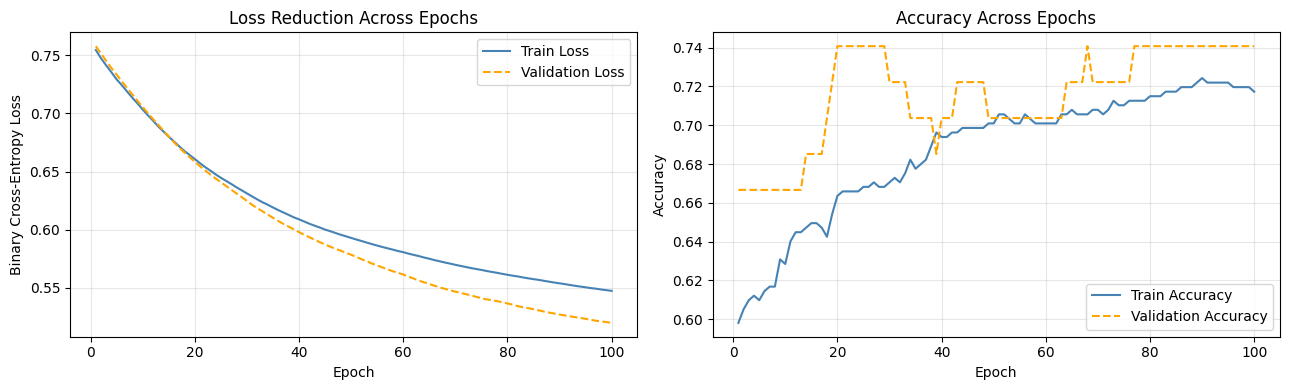


Training stopped at epoch 100
Final train loss     : 0.5475
Final val   loss     : 0.5200


In [ ]:
epochs_ran = len(history.history['loss'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Loss curve ───────────────────────────────────────────────────────────────
axes[0].plot(range(1, epochs_ran + 1), history.history['loss'],     label='Train Loss',      color='steelblue')
axes[0].plot(range(1, epochs_ran + 1), history.history['val_loss'], label='Validation Loss', color='orange',  linestyle='--')
axes[0].set_title('Loss Reduction Across Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Accuracy curve ───────────────────────────────────────────────────────────
axes[1].plot(range(1, epochs_ran + 1), history.history['accuracy'],     label='Train Accuracy',      color='steelblue')
axes[1].plot(range(1, epochs_ran + 1), history.history['val_accuracy'], label='Validation Accuracy', color='orange',  linestyle='--')
axes[1].set_title('Accuracy Across Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nTraining stopped at epoch {epochs_ran}')
print(f'Final train loss     : {history.history["loss"][-1]:.4f}')
print(f'Final val   loss     : {history.history["val_loss"][-1]:.4f}')